## import libraries and Data

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [130]:
plt.style.available
# plt.style.use('tableau-colorblind10')

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [131]:
df = pd.read_csv('UBERDATA.csv')
pd.set_option('display.max_columns' , None  )
pd.set_option('display.max_rows' , None  )
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


## Data Explor

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [134]:
df.isna().sum().nlargest(21)

Incomplete Rides Reason              141000
Incomplete Rides                     141000
Reason for cancelling by Customer    139500
Cancelled Rides by Customer          139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Driver Ratings                        57000
Customer Rating                       57000
Avg CTAT                              48000
Ride Distance                         48000
Booking Value                         48000
Payment Method                        48000
Avg VTAT                              10500
Customer ID                               0
Booking Status                            0
Booking ID                                0
Time                                      0
Date                                      0
Pickup Location                           0
Drop Location                             0
Vehicle Type                              0
dtype: int64

<Axes: >

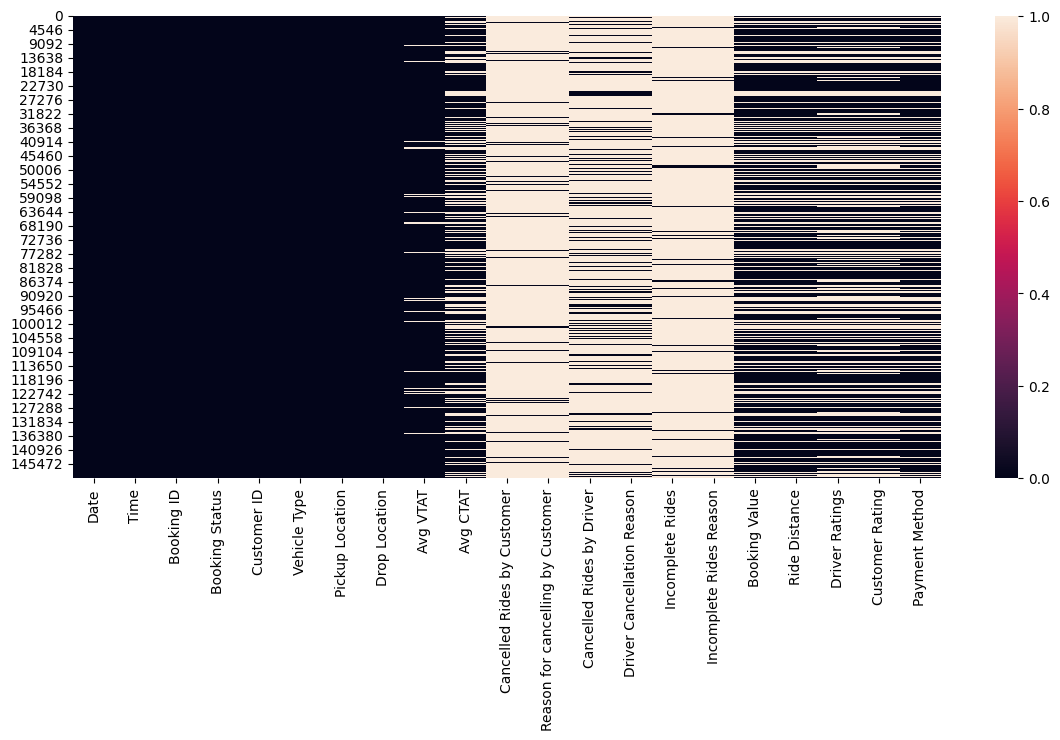

In [135]:
plt.figure(figsize=(14,6))
sns.heatmap(df.isna())

In [136]:
df.describe().round()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.0,102000.0,10500.0,27000.0,9000.0,102000.0,102000.0,93000.0,93000.0
mean,8.0,29.0,1.0,1.0,1.0,508.0,25.0,4.0,4.0
std,4.0,9.0,0.0,0.0,0.0,396.0,14.0,0.0,0.0
min,2.0,10.0,1.0,1.0,1.0,50.0,1.0,3.0,3.0
25%,5.0,22.0,1.0,1.0,1.0,234.0,12.0,4.0,4.0
50%,8.0,29.0,1.0,1.0,1.0,414.0,24.0,4.0,4.0
75%,11.0,37.0,1.0,1.0,1.0,689.0,37.0,5.0,5.0
max,20.0,45.0,1.0,1.0,1.0,4277.0,50.0,5.0,5.0


In [137]:
df.duplicated().sum()

np.int64(0)

In [138]:
print('start : ',df['Date'].min())
print('end   : ',df['Date'].max())

start :  2024-01-01
end   :  2024-12-30


## Data preprocessing

In [139]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')

df['Hour'] = df['Time'].dt.hour
df['Day'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month


In [140]:
Completed                = df.loc[df['Booking Status'] == 'Completed']
Cancelled_by_Driver      = df.loc[df['Booking Status'] == 'Cancelled by Driver' ]
No_Driver_Found          = df.loc[df['Booking Status'] == 'No Driver Found']
Cancelled_by_Customer    = df.loc[df['Booking Status'] == 'Cancelled by Customer']
Incomplete               = df.loc[df['Booking Status'] == 'Incomplete']

## Data analysis and visualization

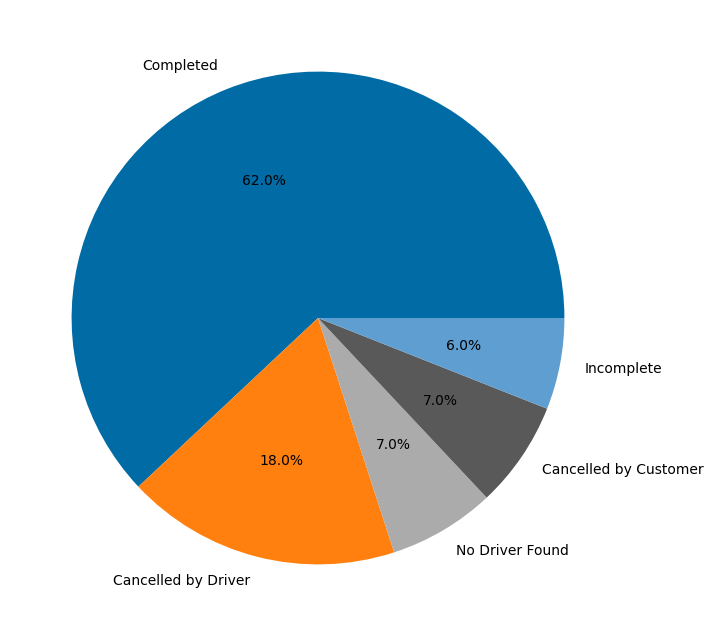

In [141]:
plt.style.use('tableau-colorblind10')
plt.figure(figsize=(8,8))
plt.pie(df['Booking Status'].value_counts(),labels=df['Booking Status'].value_counts().index,autopct='%1.1f%%',)
plt.show()

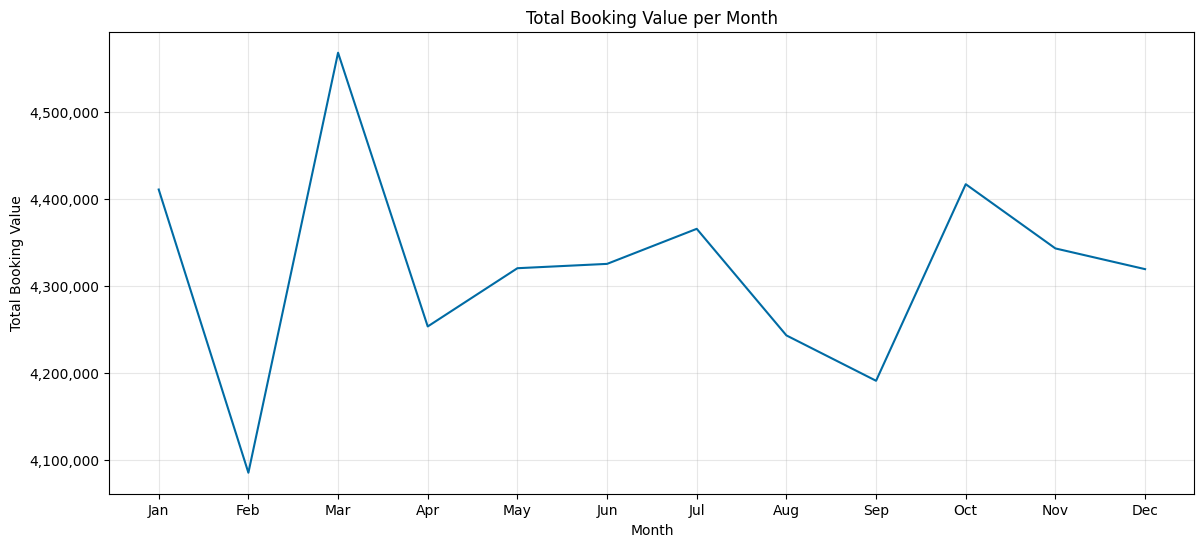

In [142]:
import matplotlib.ticker as mtick
plt.figure(figsize=(14,6))
df['month'] = df['Date'].dt.month
monthly_sales = df.groupby('month')['Booking Value'].sum()
ax = monthly_sales.plot()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax.set_xticks(range(1,13))
ax.set_xticklabels(month_names)

plt.title('Total Booking Value per Month')
plt.xlabel('Month')
plt.ylabel('Total Booking Value')
plt.grid(alpha=0.3)
plt.show()


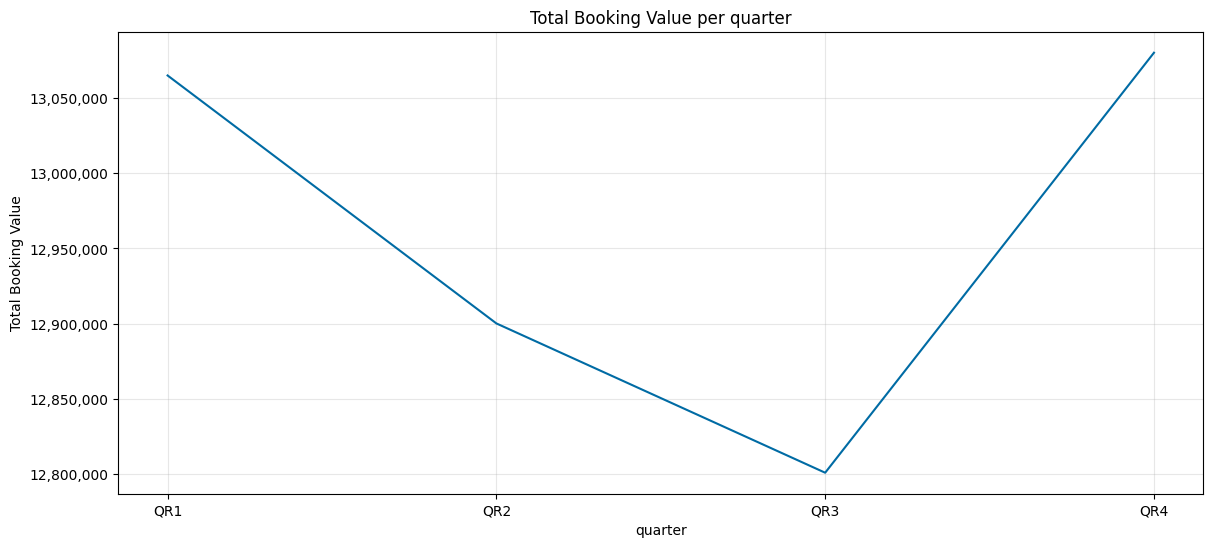

In [143]:

plt.figure(figsize=(14,6))
df['quarter'] = df['Date'].dt.quarter
quarter_sales = df.groupby('quarter')['Booking Value'].sum()
ax = quarter_sales.plot()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

month_names = ['QR1', 'QR2', 'QR3', 'QR4',]

ax.set_xticks(range(1,5))
ax.set_xticklabels(month_names)

plt.title('Total Booking Value per quarter')
plt.xlabel('quarter')
plt.ylabel('Total Booking Value')
plt.grid(alpha=0.3)
plt.show()


<Axes: xlabel='Vehicle Type'>

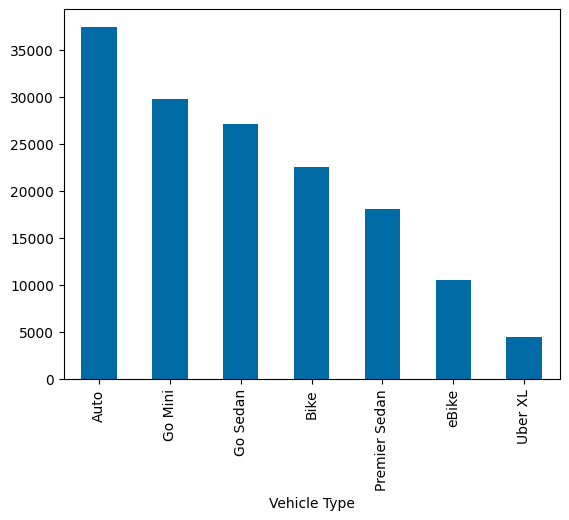

In [144]:
df['Vehicle Type'].value_counts().plot.bar()

<Axes: ylabel='count'>

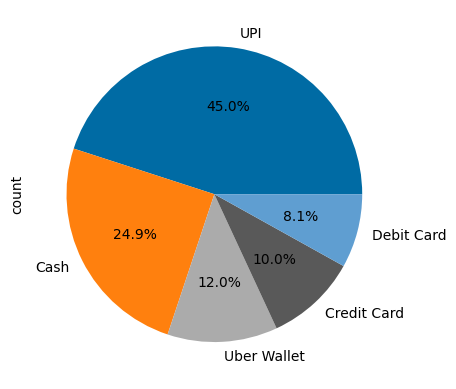

In [145]:
df['Payment Method'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: xlabel='Booking Value', ylabel='Ride Distance'>

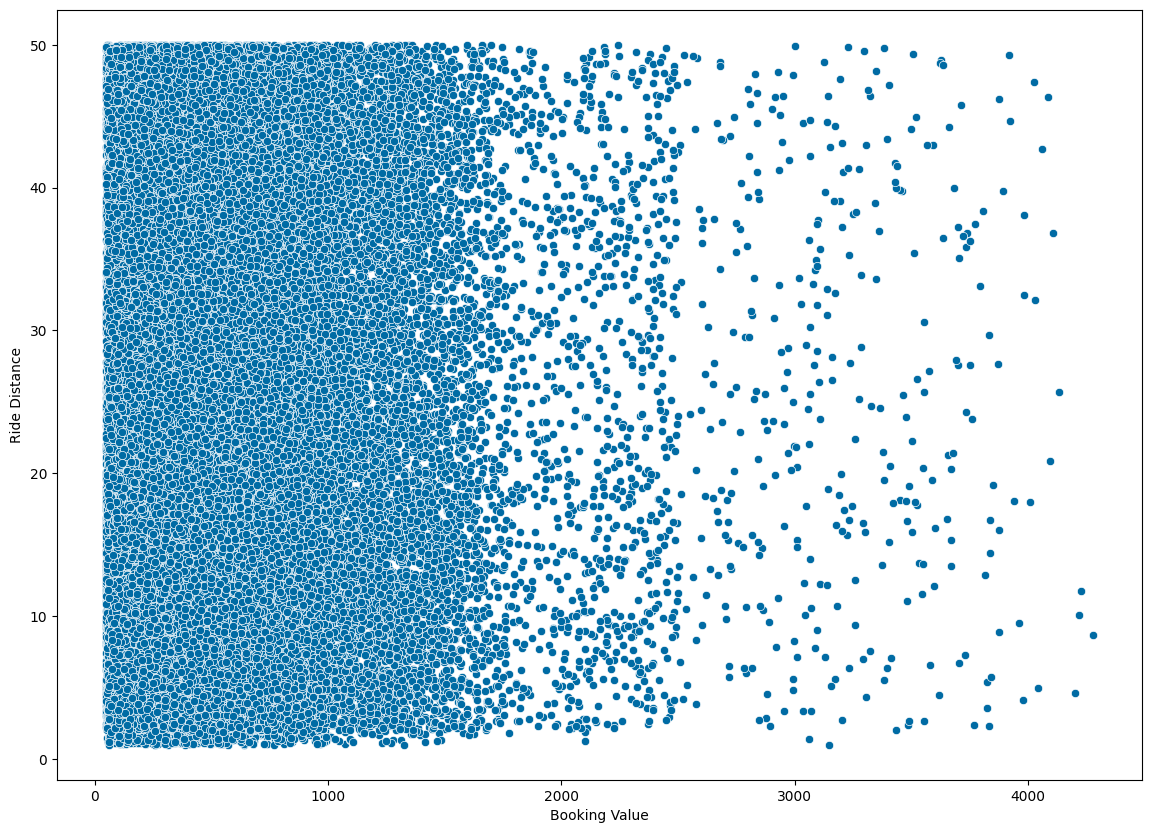

In [191]:
plt.figure(figsize=(14,10))

sns.scatterplot(
    data=df,
    x='Booking Value',
    y='Ride Distance',
)

###


### Completed            
           


In [146]:
Completed.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,Day,Month
2,2024-08-23,1900-01-01 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,8,Friday,8
3,2024-10-21,1900-01-01 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,17,Monday,10
4,2024-09-16,1900-01-01 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,22,Monday,9
5,2024-02-06,1900-01-01 09:44:56,"""CNR4096693""",Completed,"""CID4670564""",Auto,AIIMS,Narsinghpur,5.1,18.1,NaN,NaN,NaN,NaN,NaN,NaN,316.0,4.85,4.1,4.6,UPI,9,Tuesday,2
6,2024-06-17,1900-01-01 15:45:58,"""CNR2002539""",Completed,"""CID6800553""",Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,NaN,NaN,NaN,NaN,NaN,NaN,640.0,41.24,4.0,4.1,UPI,15,Monday,6


In [147]:
Completed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93000 entries, 2 to 149999
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               93000 non-null  datetime64[ns]
 1   Time                               93000 non-null  datetime64[ns]
 2   Booking ID                         93000 non-null  object        
 3   Booking Status                     93000 non-null  object        
 4   Customer ID                        93000 non-null  object        
 5   Vehicle Type                       93000 non-null  object        
 6   Pickup Location                    93000 non-null  object        
 7   Drop Location                      93000 non-null  object        
 8   Avg VTAT                           93000 non-null  float64       
 9   Avg CTAT                           93000 non-null  float64       
 10  Cancelled Rides by Customer        0 n

In [148]:
Completed[['Avg VTAT','Avg CTAT']].describe().round()

,Avg VTAT,Avg CTAT
count,93000.0,93000.0
mean,9.0,30.0
std,4.0,9.0
min,2.0,15.0
25%,5.0,23.0
50%,8.0,30.0
75%,12.0,38.0
max,15.0,45.0


<Axes: >

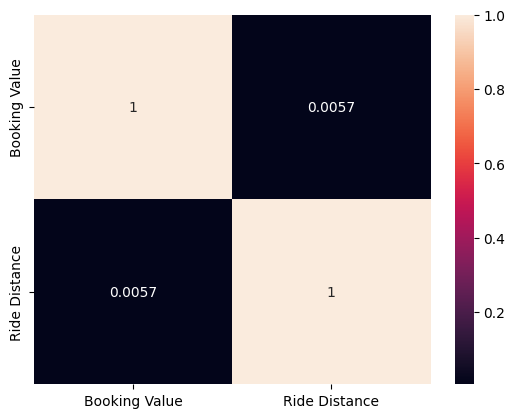

In [149]:
sns.heatmap(Completed[['Booking Value','Ride Distance']].corr(),annot=True)

In [150]:
Completed[['Driver Ratings','Customer Rating']].mean()


Driver Ratings     4.230992
Customer Rating    4.404584
dtype: float64

Text(0.5, 1.0, 'Vehicle Type')

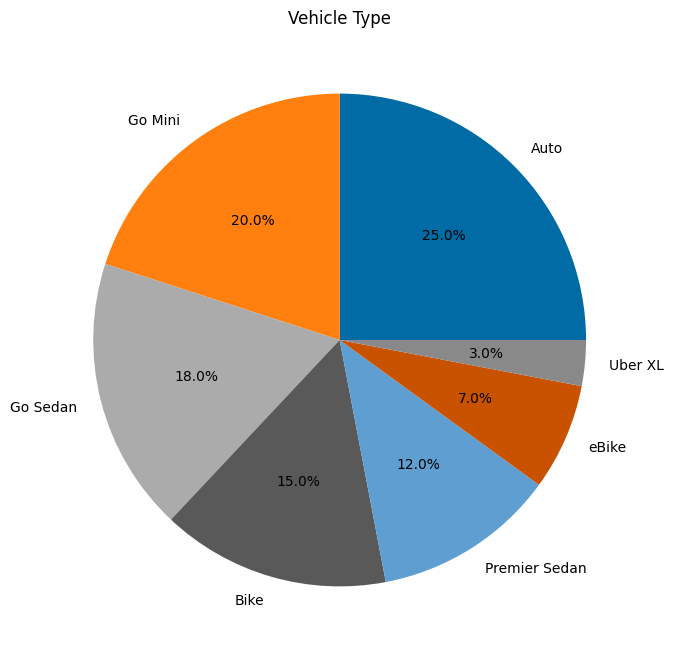

In [151]:
plt.figure(figsize=(12,8))
(Completed['Vehicle Type'].value_counts(normalize=True) * 100).round().plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.title('Vehicle Type')


Text(0.5, 1.0, 'Payment Method')

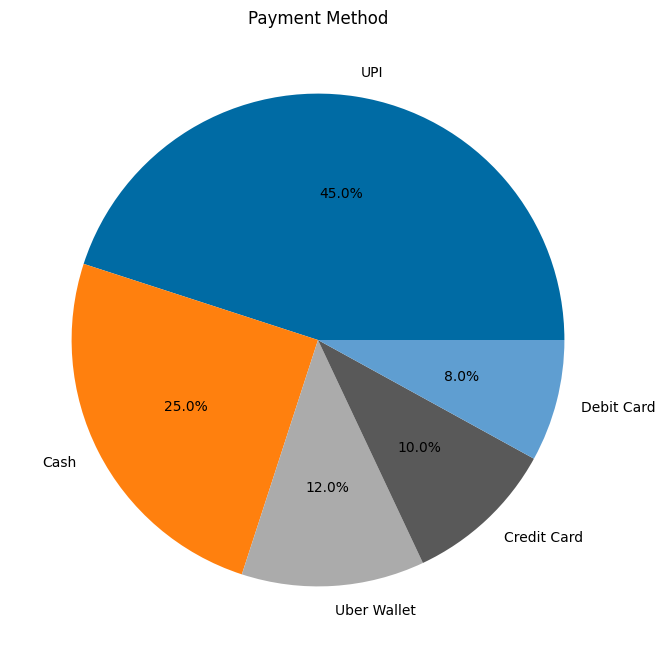

In [152]:
plt.figure(figsize=(12,8))
(Completed['Payment Method'].value_counts(normalize=True) * 100).round().plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.title('Payment Method')

### Cancelled_by_Driver  


In [153]:
Cancelled_by_Driver.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,Day,Month
12,2024-06-25,1900-01-01 22:44:15,"""CNR4386945""",Cancelled by Driver,"""CID5543520""",eBike,Patel Chowk,Kherki Daula Toll,4.6,NaN,NaN,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22,Tuesday,6
17,2024-12-15,1900-01-01 15:08:25,"""CNR6739317""",Cancelled by Driver,"""CID8682675""",Go Sedan,Vinobapuri,GTB Nagar,6.0,NaN,NaN,NaN,1.0,Customer related issue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,Sunday,12
19,2024-05-24,1900-01-01 19:53:57,"""CNR9465840""",Cancelled by Driver,"""CID9046501""",eBike,Pitampura,Rajiv Nagar,10.3,NaN,NaN,NaN,1.0,Customer related issue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19,Friday,5
26,2024-01-26,1900-01-01 09:44:00,"""CNR3614535""",Cancelled by Driver,"""CID2507102""",Auto,Cyber Hub,Saket,11.5,NaN,NaN,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,Friday,1
30,2024-05-18,1900-01-01 17:37:52,"""CNR2178654""",Cancelled by Driver,"""CID3631860""",Go Mini,Qutub Minar,Vishwavidyalaya,9.2,NaN,NaN,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17,Saturday,5


<Axes: ylabel='count'>

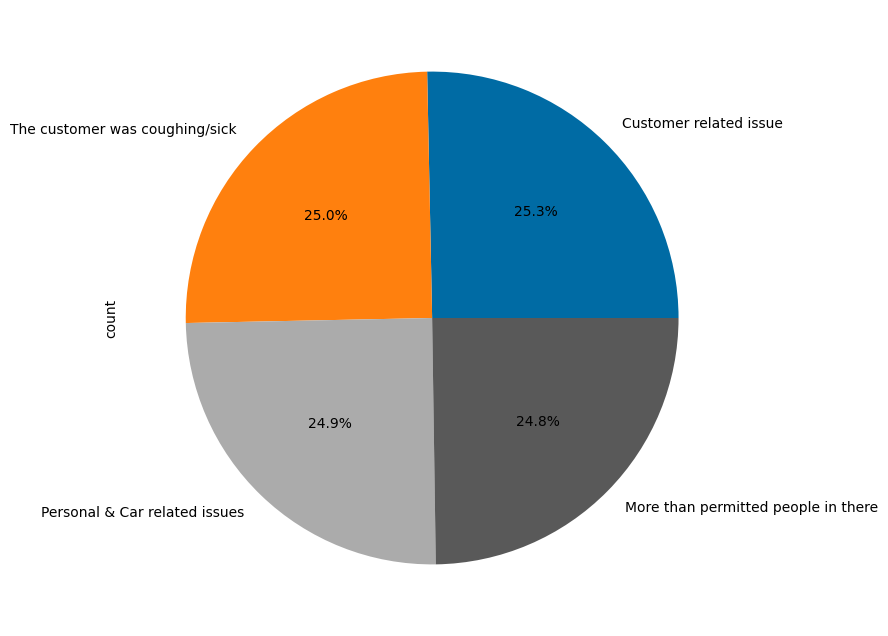

In [154]:
plt.figure(figsize=(12,8))
Cancelled_by_Driver['Driver Cancellation Reason'].value_counts().plot.pie(autopct='%1.1f%%')

In [155]:
Cancelled_by_Driver[['Avg VTAT','Avg CTAT']].mean()


Avg VTAT    7.501952
Avg CTAT         NaN
dtype: float64

In [156]:
Cancelled_by_Driver['Booking Value'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Booking Value, dtype: float64

In [157]:
Cancelled_by_Driver['Reason for cancelling by Customer'].value_counts()

Series([], Name: count, dtype: int64)

In [158]:
Cancelled_by_Driver.groupby('Hour')['Booking ID'].count()


Hour
0      248
1      250
2      222
3      263
4      240
5      532
6      699
7     1006
8     1221
9     1492
10    1715
11    1461
12    1254
13    1001
14    1311
15    1472
16    1728
17    2003
18    2257
19    1998
20    1735
21    1395
22    1011
23     486
Name: Booking ID, dtype: int64

### No_Driver_Found      


In [159]:
No_Driver_Found.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,Day,Month
0,2024-03-23,1900-01-01 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,Saturday,3
8,2024-09-14,1900-01-01 12:49:09,"""CNR4510807""",No Driver Found,"""CID7873618""",Go Sedan,Noida Sector 62,Noida Sector 18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,Saturday,9
11,2024-09-18,1900-01-01 08:09:38,"""CNR9551927""",No Driver Found,"""CID7568143""",Auto,Vidhan Sabha,AIIMS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,Wednesday,9
27,2024-04-12,1900-01-01 19:42:35,"""CNR4499383""",No Driver Found,"""CID5717521""",Premier Sedan,Sadar Bazar Gurgaon,Mehrauli,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19,Friday,4
57,2024-04-11,1900-01-01 15:43:34,"""CNR9773309""",No Driver Found,"""CID9965847""",Uber XL,Anand Vihar ISBT,Dwarka Sector 21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,Thursday,4


In [160]:
No_Driver_Found.groupby('Hour')['Booking ID'].count()


Hour
0      93
1     110
2     107
3      99
4      89
5     187
6     308
7     387
8     477
9     588
10    647
11    601
12    529
13    373
14    466
15    547
16    696
17    749
18    891
19    766
20    674
21    553
22    385
23    178
Name: Booking ID, dtype: int64

In [161]:
No_Driver_Found['Pickup Location'].value_counts().head(10)


Pickup Location
Old Gurgaon      83
Pataudi Chowk    80
Paharganj        79
Greater Noida    77
Vinobapuri       76
Rohini West      75
Dwarka Mor       72
Pitampura        72
Udyog Bhawan     71
Mehrauli         71
Name: count, dtype: int64

In [162]:
No_Driver_Found['Booking Value'].describe()


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Booking Value, dtype: float64

### Cancelled_by_Customer


In [163]:
Cancelled_by_Customer[['Avg VTAT','Avg CTAT']].mean()


Avg VTAT    12.512381
Avg CTAT          NaN
dtype: float64

In [164]:
Cancelled_by_Customer['Booking Value'].describe()


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Booking Value, dtype: float64

Text(0, 0.5, '')

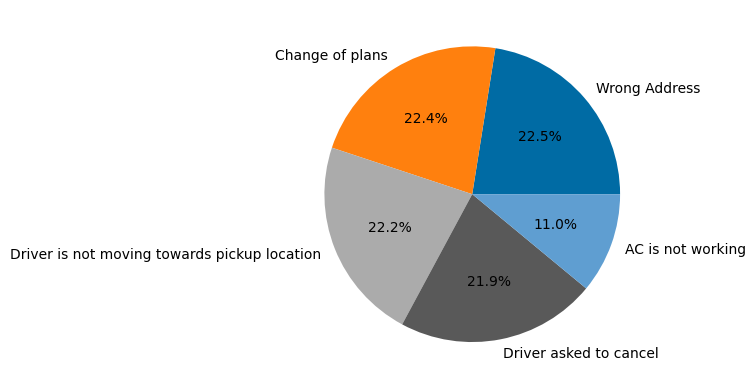

In [165]:
Cancelled_by_Customer['Reason for cancelling by Customer'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')

In [166]:
Cancelled_by_Customer.groupby('Hour')['Booking ID'].count()


Hour
0      92
1      94
2      75
3      92
4      98
5     204
6     306
7     376
8     493
9     559
10    670
11    557
12    479
13    380
14    523
15    634
16    634
17    746
18    889
19    822
20    633
21    548
22    380
23    216
Name: Booking ID, dtype: int64

### Incomplete

In [167]:
Incomplete.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,Day,Month
1,2024-11-29,1900-01-01 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,18,Friday,11
9,2024-12-16,1900-01-01 19:06:48,"""CNR7721892""",Incomplete,"""CID5214275""",Auto,Rohini,Adarsh Nagar,6.1,26.0,NaN,NaN,NaN,NaN,1.0,Other Issue,135.0,10.36,NaN,NaN,Cash,19,Monday,12
28,2024-04-05,1900-01-01 18:57:12,"""CNR9834201""",Incomplete,"""CID7891331""",Bike,Shastri Park,Botanical Garden,3.1,28.2,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,304.0,1.98,NaN,NaN,UPI,18,Friday,4
42,2024-02-12,1900-01-01 19:42:39,"""CNR4130953""",Incomplete,"""CID3196782""",Premier Sedan,Panipat,Tagore Garden,6.4,10.5,NaN,NaN,NaN,NaN,1.0,Other Issue,966.0,18.30,NaN,NaN,Debit Card,19,Monday,2
47,2024-09-30,1900-01-01 13:10:50,"""CNR4674790""",Incomplete,"""CID4795905""",Bike,Dilshad Garden,Nehru Place,2.3,29.7,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,453.0,19.24,NaN,NaN,Debit Card,13,Monday,9


In [168]:
Incomplete[['Avg VTAT','Avg CTAT']].mean()


Avg VTAT     6.013744
Avg CTAT    20.003233
dtype: float64

In [169]:
Incomplete['Incomplete Rides Reason'].value_counts()


Incomplete Rides Reason
Customer Demand      3040
Vehicle Breakdown    3012
Other Issue          2948
Name: count, dtype: int64

In [170]:
Incomplete[['Driver Ratings','Customer Rating']].describe()


,Driver Ratings,Customer Rating
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


## Machine Learning model "cluster"

In [171]:
feature = df[['Booking Status','Vehicle Type','Avg VTAT','Avg CTAT','Day','Month','Hour','Pickup Location','Booking Value','Ride Distance']]
Data = df[['Booking Status','Vehicle Type','Avg VTAT','Avg CTAT','Day','Month','Hour','Pickup Location','Booking Value','Ride Distance']]

In [172]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,Day,Month,month,quarter
0,2024-03-23,1900-01-01 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,Saturday,3,3,1
1,2024-11-29,1900-01-01 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,18,Friday,11,11,4
2,2024-08-23,1900-01-01 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,8,Friday,8,8,3
3,2024-10-21,1900-01-01 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,17,Monday,10,10,4
4,2024-09-16,1900-01-01 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,22,Monday,9,9,3


In [173]:
feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Booking Status   150000 non-null  object 
 1   Vehicle Type     150000 non-null  object 
 2   Avg VTAT         139500 non-null  float64
 3   Avg CTAT         102000 non-null  float64
 4   Day              150000 non-null  object 
 5   Month            150000 non-null  int32  
 6   Hour             150000 non-null  int32  
 7   Pickup Location  150000 non-null  object 
 8   Booking Value    102000 non-null  float64
 9   Ride Distance    102000 non-null  float64
dtypes: float64(4), int32(2), object(4)
memory usage: 10.3+ MB


In [174]:
feature.dropna(inplace= True)
Data.dropna(inplace= True)

C:\Users\OfficemaxPC\AppData\Local\Temp\ipykernel_19852\4259157483.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature.dropna(inplace= True)
C:\Users\OfficemaxPC\AppData\Local\Temp\ipykernel_19852\4259157483.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data.dropna(inplace= True)


In [175]:
feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102000 entries, 1 to 149999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Booking Status   102000 non-null  object 
 1   Vehicle Type     102000 non-null  object 
 2   Avg VTAT         102000 non-null  float64
 3   Avg CTAT         102000 non-null  float64
 4   Day              102000 non-null  object 
 5   Month            102000 non-null  int32  
 6   Hour             102000 non-null  int32  
 7   Pickup Location  102000 non-null  object 
 8   Booking Value    102000 non-null  float64
 9   Ride Distance    102000 non-null  float64
dtypes: float64(4), int32(2), object(4)
memory usage: 7.8+ MB


In [176]:
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.cluster import KMeans
cat = ['Booking Status','Vehicle Type','Day','Pickup Location']
lab = LabelEncoder()
for i in cat:
    feature[i] = lab.fit_transform(feature[i])
feature.head()

C:\Users\OfficemaxPC\AppData\Local\Temp\ipykernel_19852\2229778031.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature[i] = lab.fit_transform(feature[i])
C:\Users\OfficemaxPC\AppData\Local\Temp\ipykernel_19852\2229778031.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature[i] = lab.fit_transform(feature[i])
C:\Users\OfficemaxPC\AppData\Local\Temp\ipykernel_19852\2229778031.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

,Booking Status,Vehicle Type,Avg VTAT,Avg CTAT,Day,Month,Hour,Pickup Location,Booking Value,Ride Distance
1,1,3,4.9,14.0,0,11,18,149,237.0,5.73
2,0,0,13.4,25.8,0,8,8,80,627.0,13.58
3,0,4,13.1,28.5,1,10,17,21,416.0,34.02
4,0,1,5.3,19.6,1,9,22,39,737.0,48.21
5,0,0,5.1,18.1,5,2,9,0,316.0,4.85


In [177]:
feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102000 entries, 1 to 149999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Booking Status   102000 non-null  int64  
 1   Vehicle Type     102000 non-null  int64  
 2   Avg VTAT         102000 non-null  float64
 3   Avg CTAT         102000 non-null  float64
 4   Day              102000 non-null  int64  
 5   Month            102000 non-null  int32  
 6   Hour             102000 non-null  int32  
 7   Pickup Location  102000 non-null  int64  
 8   Booking Value    102000 non-null  float64
 9   Ride Distance    102000 non-null  float64
dtypes: float64(4), int32(2), int64(4)
memory usage: 7.8 MB


In [178]:
scl = StandardScaler()
feature = scl.fit_transform(feature)
feature

array([[ 3.21455025,  0.48009168, -0.91361129, ...,  1.20729201,
        -0.68543023, -1.35030121],
       [-0.31108551, -1.20106704,  1.37617176, ..., -0.14859656,
         0.29990636, -0.78966981],
       [-0.31108551,  1.04047792,  1.29535589, ..., -1.30797955,
        -0.233186  ,  0.67011439],
       ...,
       [-0.31108551,  0.48009168, -1.50626102, ...,  1.14834033,
         0.86836978, -0.62183748],
       [-0.31108551, -1.20106704, -0.37483881, ..., -0.99357061,
        -0.44288584,  1.4928499 ],
       [-0.31108551,  1.04047792, -1.29075203, ..., -1.56343682,
         0.75215059, -0.24617873]], shape=(102000, 10))

In [179]:
n_cluster = []
I = []
for i in range(1,15):
    model = KMeans(n_clusters=i)
    model.fit(feature)
    n_cluster.append(i)
    I.append(round(model.inertia_))

In [180]:
clu = pd.DataFrame({'n_cluster':n_cluster,'I':I})

In [181]:
clu

,n_cluster,I
0,1,1020000
1,2,893867
2,3,822768
3,4,783249
4,5,745431
5,6,708491
6,7,681914
7,8,660345
8,9,641377
9,10,624444


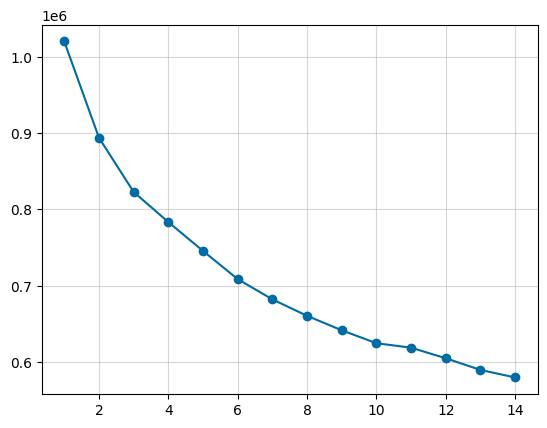

In [182]:
plt.plot(n_cluster,I,marker='o')
plt.grid(alpha=0.5)

In [183]:
model = KMeans(n_clusters=3)
model.fit(feature)
pred =model.predict(feature)

In [184]:
pred.shape

(102000,)

In [185]:
Data.shape

(102000, 10)

In [186]:
Data['Cluster'] = pred

C:\Users\OfficemaxPC\AppData\Local\Temp\ipykernel_19852\3603433004.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data['Cluster'] = pred


In [187]:
Data.head()

,Booking Status,Vehicle Type,Avg VTAT,Avg CTAT,Day,Month,Hour,Pickup Location,Booking Value,Ride Distance,Cluster
1,Incomplete,Go Sedan,4.9,14.0,Friday,11,18,Shastri Nagar,237.0,5.73,2
2,Completed,Auto,13.4,25.8,Friday,8,8,Khandsa,627.0,13.58,0
3,Completed,Premier Sedan,13.1,28.5,Monday,10,17,Central Secretariat,416.0,34.02,1
4,Completed,Bike,5.3,19.6,Monday,9,22,Ghitorni Village,737.0,48.21,1
5,Completed,Auto,5.1,18.1,Tuesday,2,9,AIIMS,316.0,4.85,0


In [188]:
# fig, ax = plt.subplots(figsize=(14,10))

# sns.scatterplot(Data=df1, x='Avg VTAT', y='Avg CTAT', ax=ax)
# sns.scatterplot(Data=df2, x='Avg VTAT', y='Avg CTAT', ax=ax)
# sns.scatterplot(Data=df3, x='Avg VTAT', y='Avg CTAT', ax=ax)
# sns.scatterplot(Data=df4, x='Avg VTAT', y='Avg CTAT', ax=ax)

# ax.set_title('Final cluster', fontsize=18)
# ax.legend()
# plt.show()

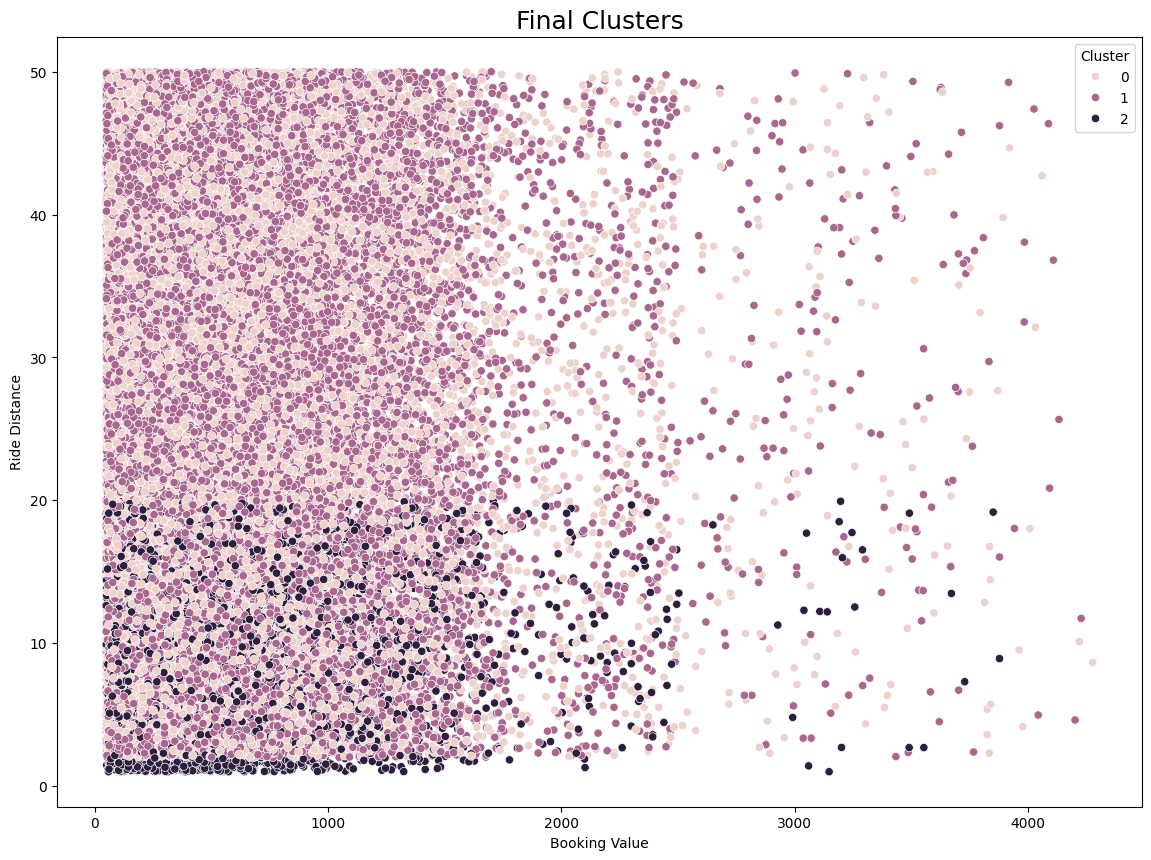

In [190]:
plt.figure(figsize=(14,10))

sns.scatterplot(
    data=Data,
    x='Booking Value',
    y='Ride Distance',
    hue='Cluster',
    # palette='Set2'
)

plt.title('Final Clusters', fontsize=18)
plt.legend(title='Cluster')
plt.show()
